<hr>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
train_data = pd.read_csv('src_data/processed/train_data.csv')
feature, label = train_data.iloc[:, :-1], train_data.iloc[:, -1]


In [9]:
print(feature.shape, label.shape)
train_data.sample(3)

(936, 6) (936,)


,age,sex,bmi,children,smoker,region,target
465,47,0,-0.495151,2,1,1,24535.69855
384,36,1,1.842482,3,1,0,43753.33705
704,33,1,-0.067815,0,0,2,3704.35450


In [10]:
Selected_Features = ['age', 'bmi', 'smoker', ] #'children', 'region', 'sex']

### evaluating different (trees/estimators) that have been trained inside single RandomForest

In [11]:
from sklearn.ensemble import RandomForestRegressor

In [12]:
RF = RandomForestRegressor()

In [13]:
RF.fit(feature[Selected_Features], label)

RandomForestRegressor()

In [14]:
all_trees = RF.estimators_
all_trees[:5],type(all_trees[:5],)

([DecisionTreeRegressor(max_features=1.0, random_state=272004597),
  DecisionTreeRegressor(max_features=1.0, random_state=2088919192),
  DecisionTreeRegressor(max_features=1.0, random_state=1495502884),
  DecisionTreeRegressor(max_features=1.0, random_state=197342214),
  DecisionTreeRegressor(max_features=1.0, random_state=76623111)],
 list)

In [15]:
feature_sample = feature.sample(20)
label_sample =   label[feature_sample.index]
# feature_sample, label_sample

## Evaluation 1 |Mean Absolute error|

In [16]:
from sklearn.metrics import mean_absolute_error

In [17]:
MAE_s = []
for i in all_trees:
    i_pred = i.predict(feature_sample[Selected_Features])
    MAE_i = mean_absolute_error(label_sample, i_pred)
    MAE_s += [MAE_i]

# MAE_s

c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature nam

c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature nam

### Visualization of MAE for all trees

Text(0.5, 1.0, 'mean absolute errors of all descision trees inside RandomForest as they predict feature_sample')

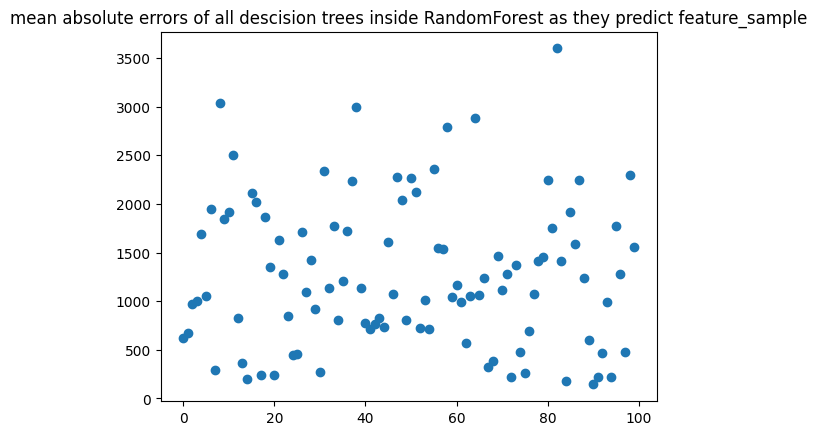

In [18]:
plt.scatter([x for x in range(100)], MAE_s)
plt.title('mean absolute errors of all descision trees inside RandomForest as they predict feature_sample')

In [19]:
## average mae_s
print(sum(MAE_s)/100)

1266.2570536191668


In [20]:
## Mean absolute error of main RF
mean_absolute_error(label_sample, RF.predict(feature_sample[Selected_Features]))

1161.0440494091679

### evaluation on feature_test_sample

In [24]:
test = pd.read_csv('src_data/processed/test_data.csv')

In [25]:
test_sample = test.sample(20)
feature_test_sample = test_sample.drop(['target'], axis=1)

In [26]:
feature_sample.head(2)

,age,sex,bmi,children,smoker,region
569,39,1,-1.445789,1,0,1
399,57,1,1.577551,0,0,0


In [27]:
label_test_sample = test_sample['target']
label_sample.head(2)

569     6117.49450
399    20709.02034
Name: target, dtype: float64

In [28]:
MAE_s2 = []
for i in all_trees:
    i_pred = i.predict(feature_test_sample[Selected_Features])
    MAE_i2 = mean_absolute_error(label_test_sample, i_pred)
    MAE_s2 += [MAE_i2]

# MAE_s

c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature nam

Text(0.5, 1.0, 'mean absolute errors of all descision trees inside RandomForest as they predict feature_test_sample')

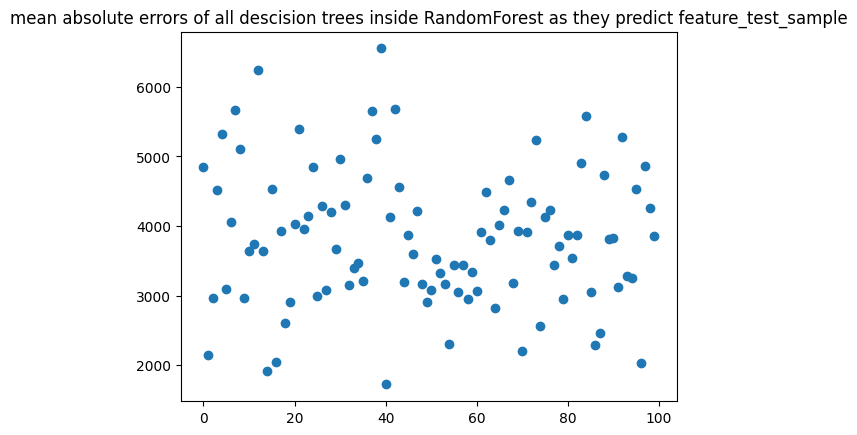

In [29]:
plt.scatter([x for x in range(100)], MAE_s2)
plt.title('mean absolute errors of all descision trees inside RandomForest as they predict feature_test_sample')

In [30]:
## average mae_s
print(sum(MAE_s2)/100)

3811.8349716625007


In [31]:
## Mean absolute error of main RF
mean_absolute_error(label_test_sample, RF.predict(feature_test_sample[Selected_Features]))

3141.4085665824978

### conclusions 1 (early early pipeline that had age feature scaled in the final data)
- randomforest's predictions have higher MAE for test_data , nearly triple the MAE on train data
- not ready to use

## Conclusion (new model)
- test MAE is 1.2 or 1.3 times higher than train_Sample mAE so this model is ready to be used.